In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score


# Loading the dataset

In [3]:
df = pd.read_csv(r"D:\UPES\Semester 2\KPMG\Predictive Modelling\Telecom_Dataset.csv")

In [4]:
df.head(10)

,Customer_ID,Tenure_Months,Monthly_Spend,Avg_Data_Usage_GB,Usage_Hours,Complaints_Last_6M,Payment_Delay_Days,Support_Calls,Contract_Type,Plan_Type,Auto_Pay,Discount_Received_%,Internet_Speed_Mbps,Region,Churn
0,1,52,958.66,14.60,101.1,1,5.8,3,2-Year,Standard,1,20,100,South,0
1,2,15,963.19,11.08,104.1,0,1.7,1,Monthly,Basic,1,0,200,West,0
2,3,61,1311.60,22.14,111.2,2,0.6,0,Annual,Standard,0,5,100,West,0
3,4,21,648.23,22.03,76.3,2,0.6,3,Annual,Basic,1,5,50,South,0
4,5,24,735.69,18.35,135.8,2,4.4,2,Annual,Standard,1,0,100,West,1
5,6,3,665.66,14.04,66.4,1,0.9,1,Monthly,Premium,0,20,200,West,0
6,7,22,482.56,15.01,87.9,2,4.4,1,Annual,Standard,1,0,50,South,0
7,8,53,1341.17,7.34,115.7,2,0.7,4,2-Year,Standard,0,0,25,West,0
8,9,2,589.62,21.68,84.7,2,1.2,1,Annual,Standard,1,0,25,North,0
9,10,30,695.92,21.47,123.3,0,1.9,2,Monthly,Basic,1,10,25,North,0


In [5]:
print(df.describe())

       Customer_ID  Tenure_Months  Monthly_Spend  Avg_Data_Usage_GB  \
count  1000.000000    1000.000000    1000.000000         1000.00000   
mean    500.500000      35.489000     898.912650           14.91278   
std     288.819436      20.709485     243.290905            5.93042   
min       1.000000       1.000000     300.000000            1.00000   
25%     250.750000      17.000000     728.005000           10.83500   
50%     500.500000      35.000000     906.870000           14.85500   
75%     750.250000      54.000000    1058.452500           18.99500   
max    1000.000000      71.000000    1641.250000           33.37000   

       Usage_Hours  Complaints_Last_6M  Payment_Delay_Days  Support_Calls  \
count  1000.000000         1000.000000         1000.000000     1000.00000   
mean     99.792200            1.175000            2.804700        2.00000   
std      29.659595            1.043774            2.782871        1.37982   
min      20.000000            0.000000            0.

# Phase 1: Data Integrity & Univariate Analysis

In [6]:
df.isnull().sum()

Customer_ID            0
Tenure_Months          0
Monthly_Spend          0
Avg_Data_Usage_GB      0
Usage_Hours            0
Complaints_Last_6M     0
Payment_Delay_Days     0
Support_Calls          0
Contract_Type          0
Plan_Type              0
Auto_Pay               0
Discount_Received_%    0
Internet_Speed_Mbps    0
Region                 0
Churn                  0
dtype: int64

In [7]:
df.duplicated().any()

np.False_

In [8]:
df.T.duplicated().any()

np.False_

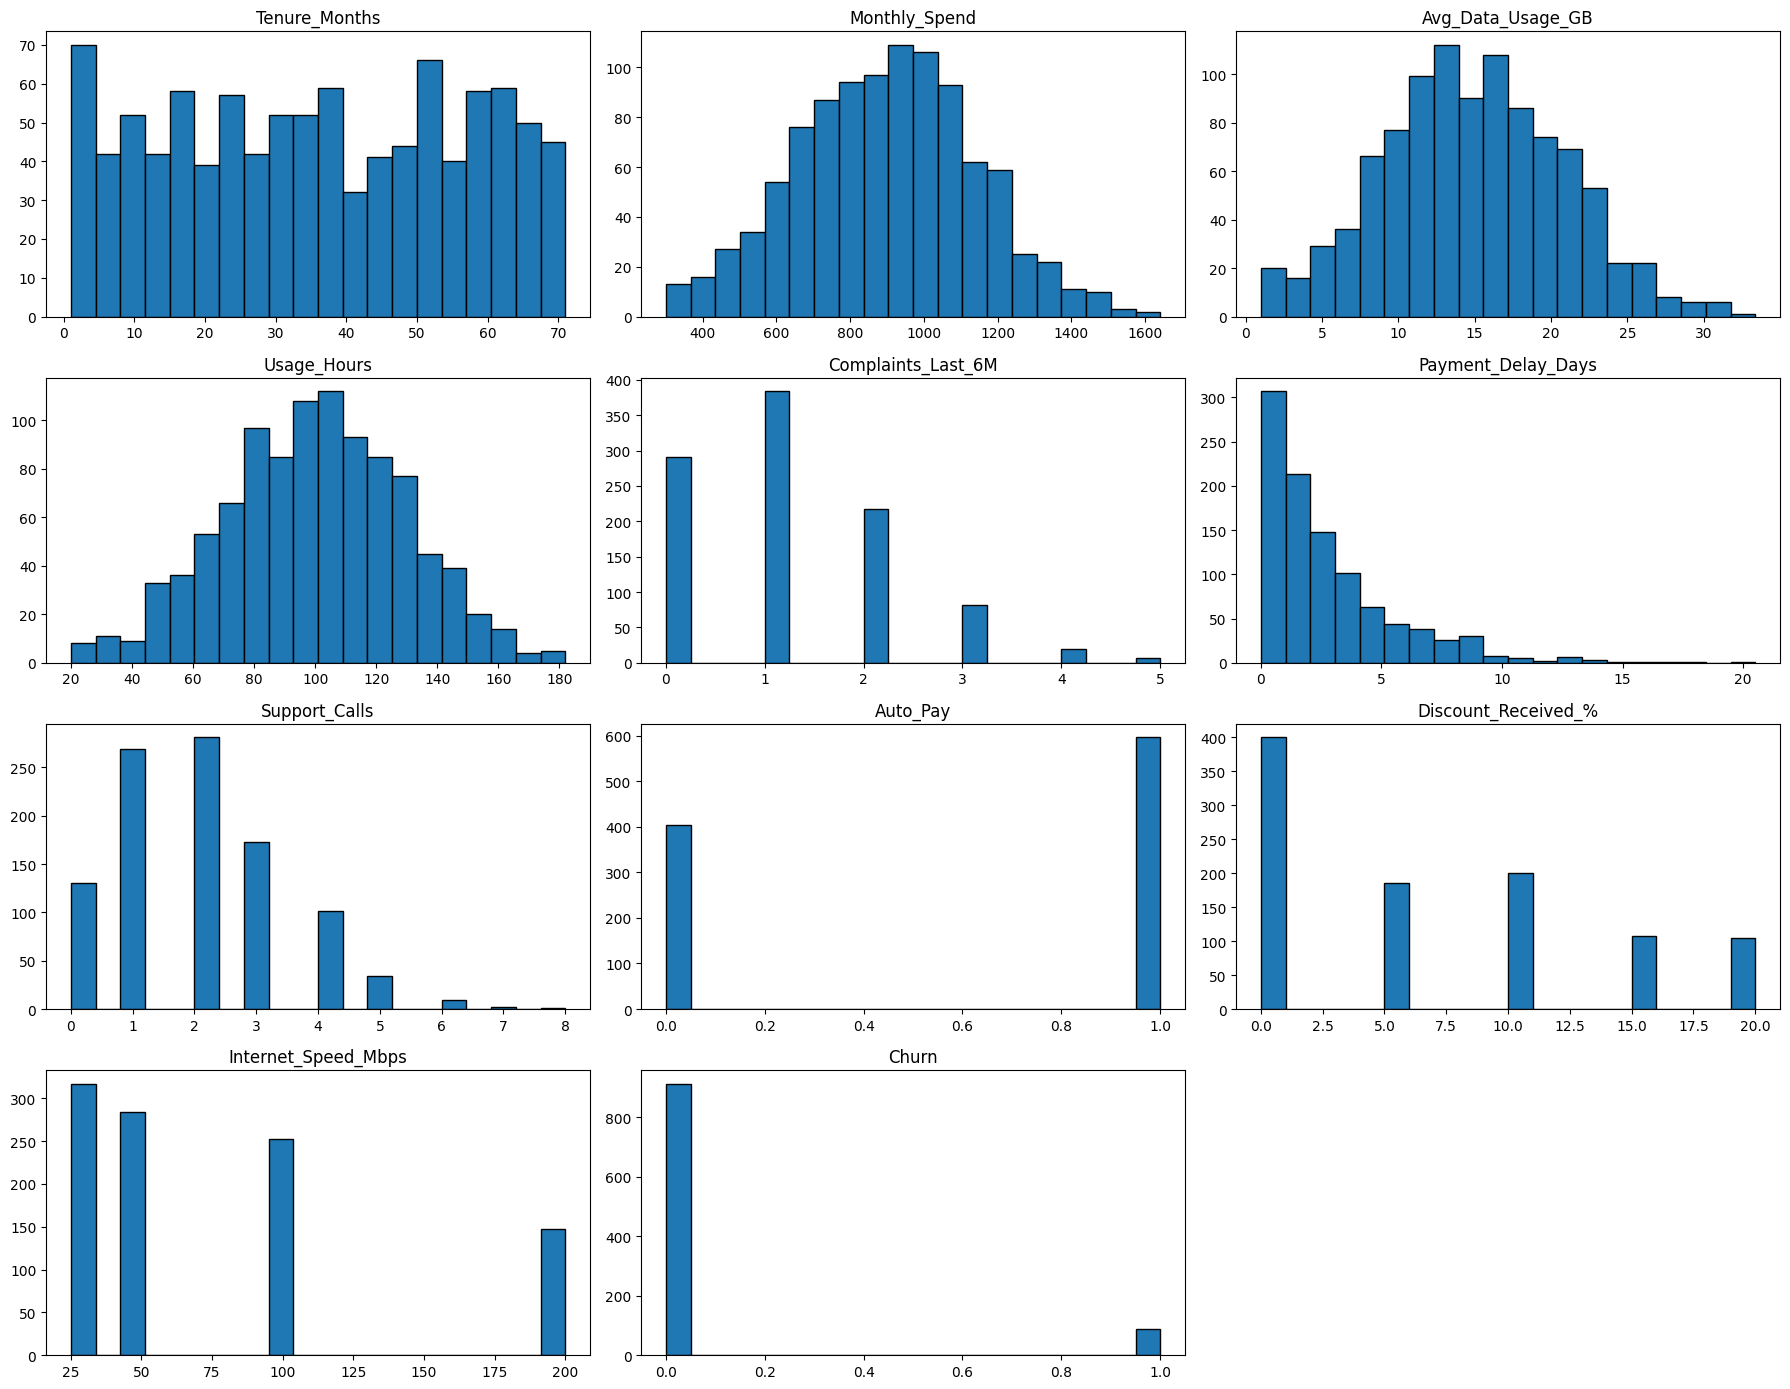

In [9]:
numeric_df = df.select_dtypes(include=['int64','float64'])
numeric_df.drop(columns=['Customer_ID'],inplace = True)
numeric_df.hist(figsize=(18,14),bins=20,edgecolor='black',grid=False)
plt.tight_layout()
plt.show()

# Phase 2: The Statistical Tests

## Shapiro - Wilk test

In [10]:
from scipy.stats import shapiro

In [11]:
for col in numeric_df:
    stat, p = shapiro(numeric_df[col])
    print(f"{col}:p-value={p}")

Tenure_Months:p-value=8.73846399857174e-18
Monthly_Spend:p-value=0.20546698317030593
Avg_Data_Usage_GB:p-value=0.06442226788223812
Usage_Hours:p-value=0.23937340837789112
Complaints_Last_6M:p-value=8.457694070836181e-29
Payment_Delay_Days:p-value=7.26383134215863e-32
Support_Calls:p-value=4.459407650319239e-22
Auto_Pay:p-value=4.020205154881026e-42
Discount_Received_%:p-value=5.680618352105389e-31
Internet_Speed_Mbps:p-value=2.0583344918038819e-35
Churn:p-value=2.7779062405936455e-51


In [12]:
skewed_cols = ['Payment_Delay_Days','Complaints_Last_6M','Support_Calls']

## Tests of Significance

### T-Test

In [13]:
from scipy.stats import ttest_ind
continous_col = ['Monthly_Spend','Avg_Data_Usage_GB','Usage_Hours','Payment_Delay_Days','Tenure_Months']
for col in continous_col:
    churn_0 = df[df['Churn']==0][col]
    churn_1 = df[df['Churn']==1][col]
    stat, p = ttest_ind(churn_0, churn_1)
    print(f"{col}: p-value = {p}")

Monthly_Spend: p-value = 0.7186796008298556
Avg_Data_Usage_GB: p-value = 0.7020997712955765
Usage_Hours: p-value = 0.8191775144527665
Payment_Delay_Days: p-value = 0.3846371750799802
Tenure_Months: p-value = 1.1845644137638444e-12


### Chi-Square Test

In [14]:
from scipy.stats import chi2_contingency
categorical_cols = ['Auto_Pay','Internet_Speed_Mbps','Discount_Received_%']

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    stat, p, dof, expected = chi2_contingency(contingency_table)
    print(contingency_table)
    print(f"{col}: p-value = {p}")

Churn       0   1
Auto_Pay         
0         358  46
1         554  42
Auto_Pay: p-value = 0.023636121327738988
Churn                  0   1
Internet_Speed_Mbps         
25                   293  24
50                   255  29
100                  236  16
200                  128  19
Internet_Speed_Mbps: p-value = 0.0977084509320895
Churn                  0   1
Discount_Received_%         
0                    362  38
5                    170  16
10                   181  20
15                   100   8
20                    99   6
Discount_Received_%: p-value = 0.7189612712163727


## Multicollinarity

### VIF

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [16]:
X = df.drop(columns=['Churn','Customer_ID'])
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                  feature        VIF
0                   const  55.931022
1           Tenure_Months   1.034210
2           Monthly_Spend   1.012823
3       Avg_Data_Usage_GB   1.009582
4             Usage_Hours   1.015777
5      Complaints_Last_6M   1.011163
6      Payment_Delay_Days   1.041318
7           Support_Calls   1.007973
8                Auto_Pay   1.010753
9     Discount_Received_%   1.015483
10    Internet_Speed_Mbps   1.009145
11   Contract_Type_Annual   1.718270
12  Contract_Type_Monthly   1.702312
13      Plan_Type_Premium   1.239606
14     Plan_Type_Standard   1.238993
15           Region_North   1.644467
16           Region_South   1.649978
17            Region_West   1.633164


# Phase 3: Pre-processing

## Outliers

In [17]:
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

In [18]:
X.columns

Index(['const', 'Tenure_Months', 'Monthly_Spend', 'Avg_Data_Usage_GB',
       'Usage_Hours', 'Complaints_Last_6M', 'Payment_Delay_Days',
       'Support_Calls', 'Auto_Pay', 'Discount_Received_%',
       'Internet_Speed_Mbps', 'Contract_Type_Annual', 'Contract_Type_Monthly',
       'Plan_Type_Premium', 'Plan_Type_Standard', 'Region_North',
       'Region_South', 'Region_West'],
      dtype='object')

In [19]:
numeric_df.columns

Index(['Tenure_Months', 'Monthly_Spend', 'Avg_Data_Usage_GB', 'Usage_Hours',
       'Complaints_Last_6M', 'Payment_Delay_Days', 'Support_Calls', 'Auto_Pay',
       'Discount_Received_%', 'Internet_Speed_Mbps', 'Churn'],
      dtype='object')

In [20]:
numeric_df.drop(columns=['Churn','Auto_Pay'],inplace=True)

In [21]:
standard = StandardScaler()
df[numeric_df.columns] = standard.fit_transform(df[numeric_df.columns])

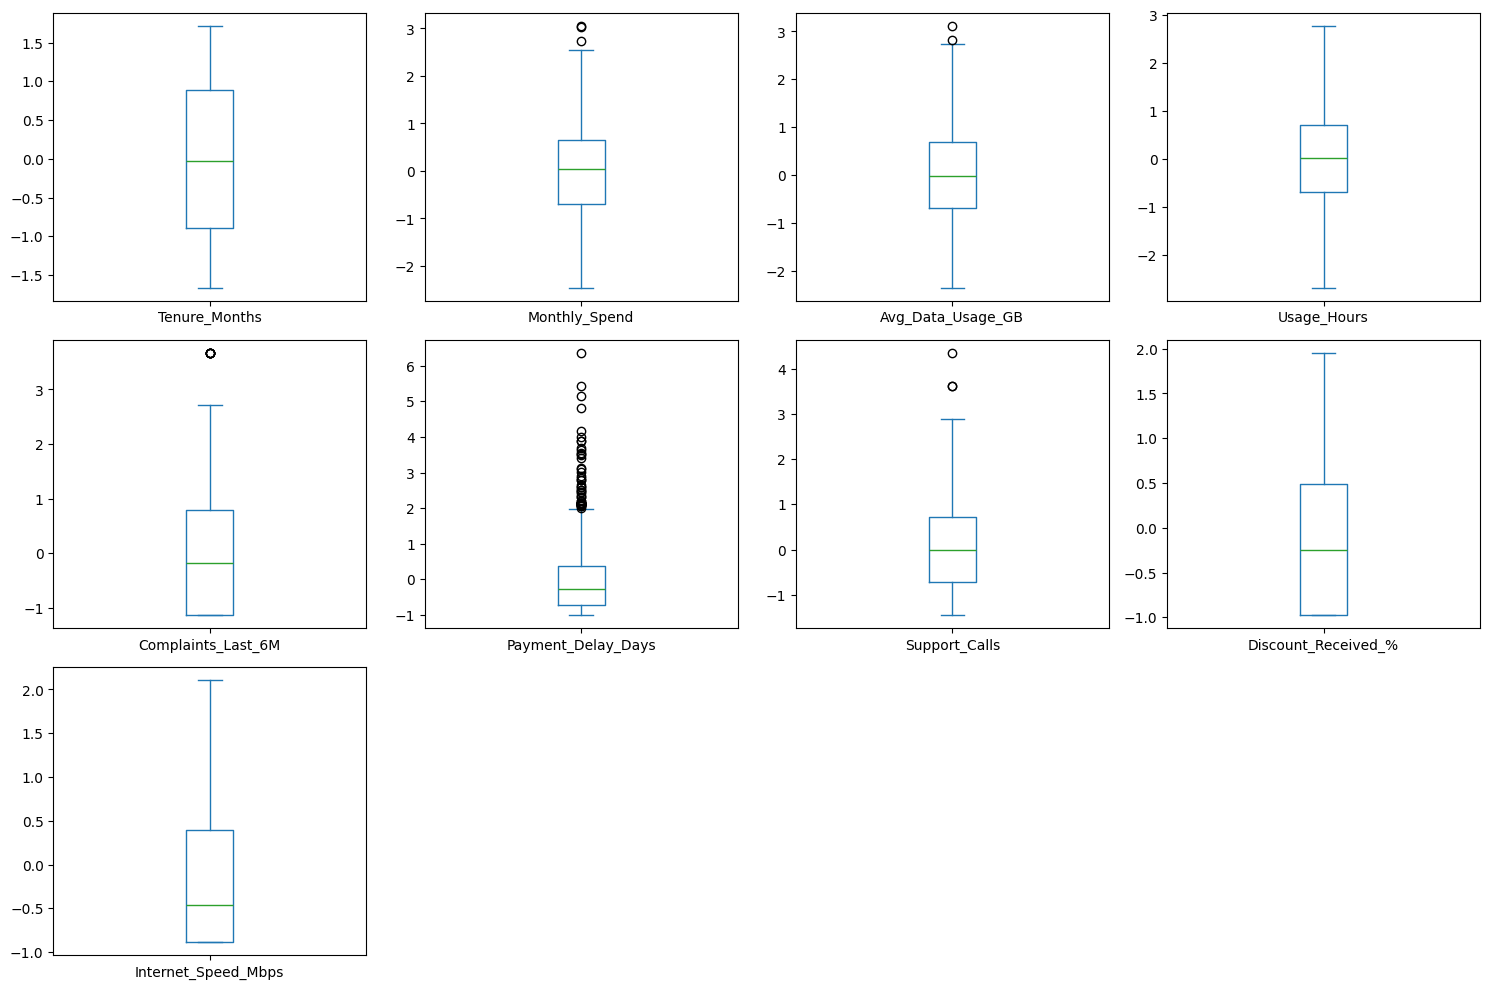

In [22]:
df[numeric_df.columns].plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10))
plt.tight_layout()
plt.show()

In [23]:
remove_outliers(X, numeric_df.columns)

,const,Tenure_Months,Monthly_Spend,Avg_Data_Usage_GB,Usage_Hours,Complaints_Last_6M,Payment_Delay_Days,Support_Calls,Auto_Pay,Discount_Received_%,Internet_Speed_Mbps,Contract_Type_Annual,Contract_Type_Monthly,Plan_Type_Premium,Plan_Type_Standard,Region_North,Region_South,Region_West
0,1.0,52.0,958.66,14.60,101.1,1.0,5.8,3.0,1.0,20.0,100.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,15.0,963.19,11.08,104.1,0.0,1.7,1.0,1.0,0.0,200.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,61.0,1311.60,22.14,111.2,2.0,0.6,0.0,0.0,5.0,100.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,21.0,648.23,22.03,76.3,2.0,0.6,3.0,1.0,5.0,50.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,24.0,735.69,18.35,135.8,2.0,4.4,2.0,1.0,0.0,100.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,51.0,1214.26,20.66,104.2,1.0,0.0,4.0,0.0,10.0,100.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
996,1.0,8.0,520.39,15.09,133.6,1.0,5.5,1.0,0.0,20.0,100.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,1.0,34.0,1210.96,21.29,116.5,2.0,0.1,1.0,0.0,0.0,200.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
998,1.0,35.0,874.24,8.17,120.8,0.0,8.3,3.0,1.0,0.0,50.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [24]:
standard = StandardScaler()
X[numeric_df.columns] = standard.fit_transform(X[numeric_df.columns])

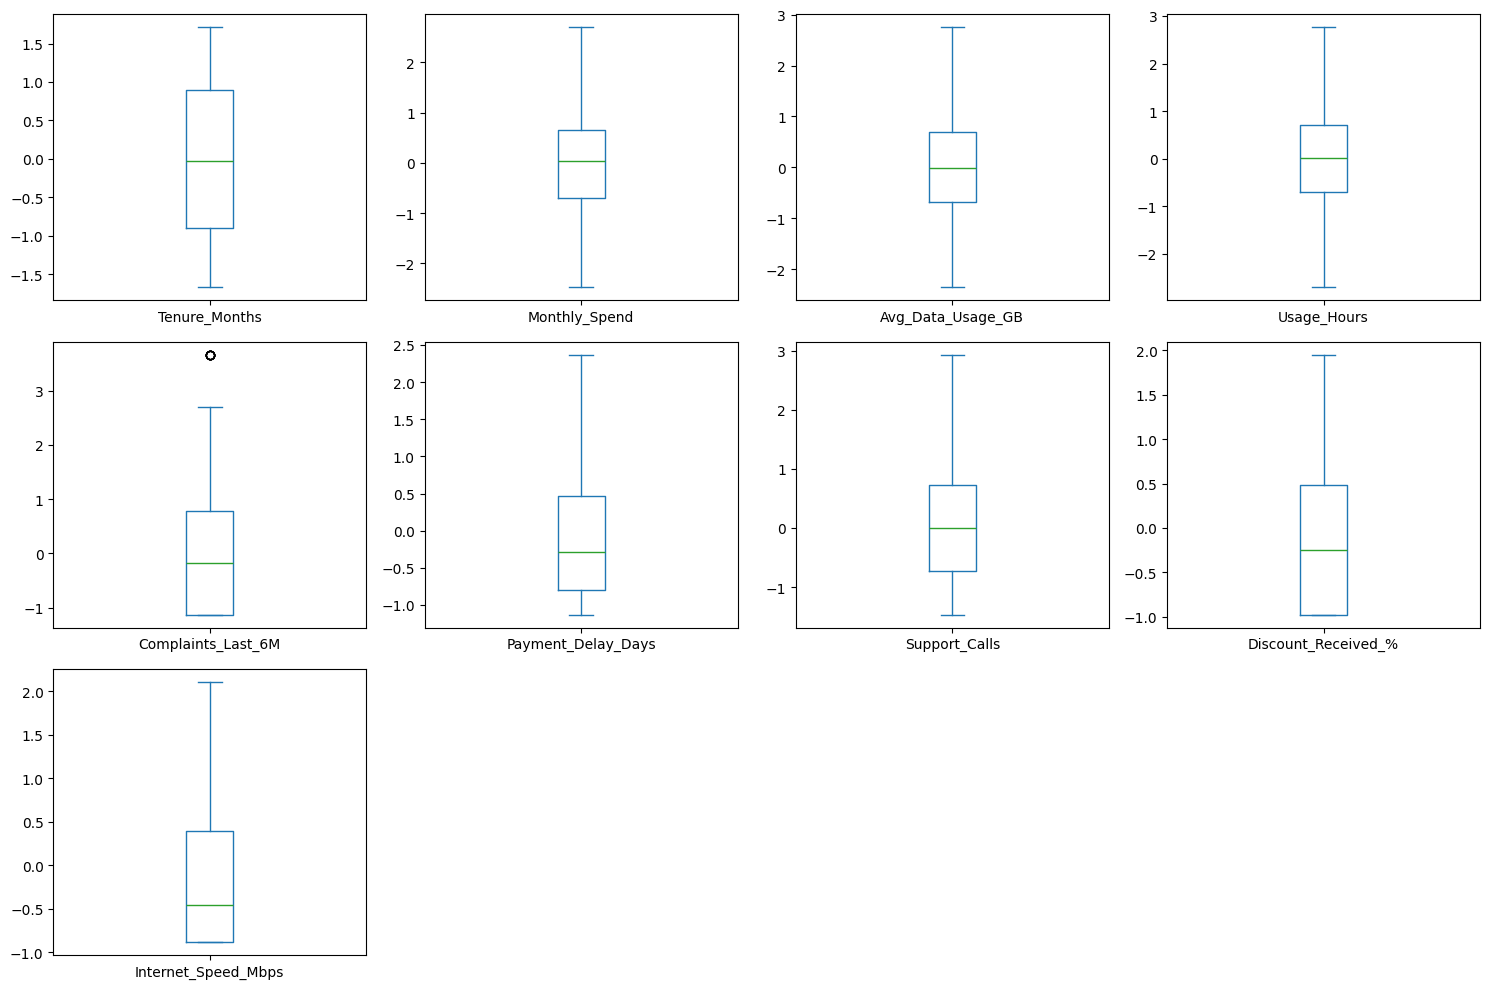

In [25]:
X[numeric_df.columns].plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10))
plt.tight_layout()
plt.show()

## Transformation

In [26]:
for col in skewed_cols:
    df[col] = np.log1p(df[col])

c:\Users\Gaurav Bhakta\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Phase 4: Modeling & Critical Analysis

In [27]:
y = df['Churn']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

## Logistic Regression

In [29]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
y_predict = lr.predict(X_test)
print(classification_report(y_test, y_predict))
print(confusion_matrix(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.98      0.69      0.81       182
           1       0.22      0.89      0.35        18

    accuracy                           0.70       200
   macro avg       0.60      0.79      0.58       200
weighted avg       0.92      0.70      0.77       200

[[125  57]
 [  2  16]]


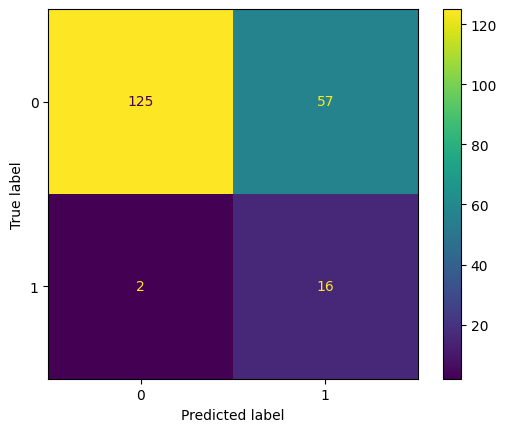

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict)
plt.show()

(0.0, 1.0)

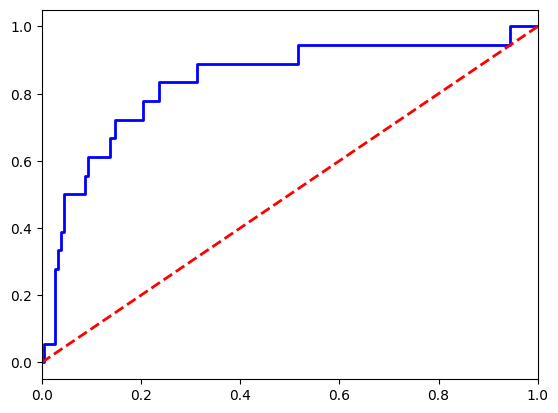

In [31]:
roc_curve(y_test, lr.predict_proba(X_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, lr.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])

In [32]:
y_prob = lr.predict_proba(X_test)[:, 1]

In [33]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append((t, precision, recall, f1))

for r in results:
    print(f"Threshold={r[0]:.2f} | Precision={r[1]:.2f} | Recall={r[2]:.2f} | F1={r[3]:.2f}")

Threshold=0.10 | Precision=0.10 | Recall=0.94 | F1=0.18
Threshold=0.15 | Precision=0.11 | Recall=0.94 | F1=0.19
Threshold=0.20 | Precision=0.11 | Recall=0.94 | F1=0.20
Threshold=0.25 | Precision=0.13 | Recall=0.94 | F1=0.23
Threshold=0.30 | Precision=0.14 | Recall=0.94 | F1=0.24
Threshold=0.35 | Precision=0.15 | Recall=0.94 | F1=0.26
Threshold=0.40 | Precision=0.16 | Recall=0.89 | F1=0.27
Threshold=0.45 | Precision=0.18 | Recall=0.89 | F1=0.30
Threshold=0.50 | Precision=0.22 | Recall=0.89 | F1=0.35
Threshold=0.55 | Precision=0.25 | Recall=0.83 | F1=0.38
Threshold=0.60 | Precision=0.28 | Recall=0.72 | F1=0.40
Threshold=0.65 | Precision=0.31 | Recall=0.61 | F1=0.41
Threshold=0.70 | Precision=0.36 | Recall=0.50 | F1=0.42
Threshold=0.75 | Precision=0.47 | Recall=0.50 | F1=0.49
Threshold=0.80 | Precision=0.50 | Recall=0.39 | F1=0.44
Threshold=0.85 | Precision=0.17 | Recall=0.06 | F1=0.08


In [34]:
best = max(results, key=lambda x: x[3])
print("Best Threshold:", best)

Best Threshold: (np.float64(0.7500000000000002), 0.47368421052631576, 0.5, 0.4864864864864865)


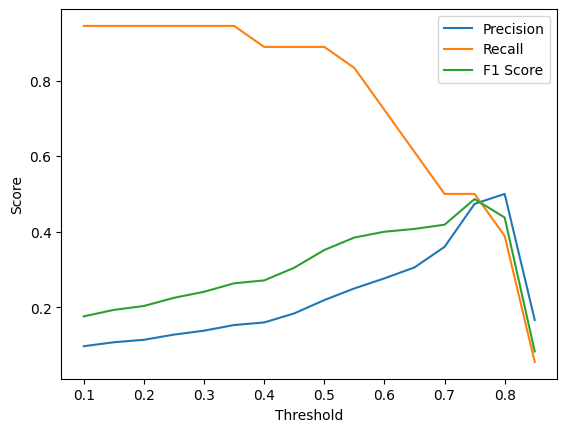

In [35]:
precisions = [r[1] for r in results]
recalls = [r[2] for r in results]
f1s = [r[3] for r in results]

plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1s, label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [36]:
best_threshold = best[0]

y_pred_final = (y_prob >= best_threshold).astype(int)


print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       182
           1       0.47      0.50      0.49        18

    accuracy                           0.91       200
   macro avg       0.71      0.72      0.72       200
weighted avg       0.91      0.91      0.91       200



In [37]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
12,Contract_Type_Monthly,1.258335,1.258335
5,Complaints_Last_6M,0.594089,0.594089
11,Contract_Type_Annual,0.550618,0.550618
17,Region_West,0.389995,0.389995
6,Payment_Delay_Days,0.363588,0.363588
0,const,0.001759,0.001759
7,Support_Calls,-0.003556,0.003556
3,Avg_Data_Usage_GB,-0.011620,0.011620
10,Internet_Speed_Mbps,-0.020358,0.020358
4,Usage_Hours,-0.051190,0.051190


## KNN

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       182
           1       0.31      0.28      0.29        18

    accuracy                           0.88       200
   macro avg       0.62      0.61      0.61       200
weighted avg       0.87      0.88      0.88       200

KNN Confusion Matrix:

[[171  11]
 [ 13   5]]


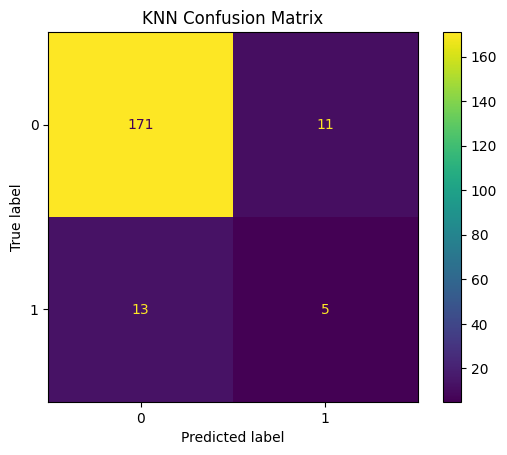

In [38]:
knn_model = KNeighborsClassifier(n_neighbors=1, weights='distance')
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("KNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN Confusion Matrix")
plt.show()

## After SMOTE

Old Training Churn Ratio:
 Churn
0    730
1     70
Name: count, dtype: int64

New SMOTE Training Churn Ratio:
 Churn
0    730
1    730
Name: count, dtype: int64
--------------------------------------------------
KNN with SMOTE Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.63      0.76       182
           1       0.15      0.67      0.25        18

    accuracy                           0.64       200
   macro avg       0.55      0.65      0.50       200
weighted avg       0.88      0.64      0.71       200

[[115  67]
 [  6  12]]


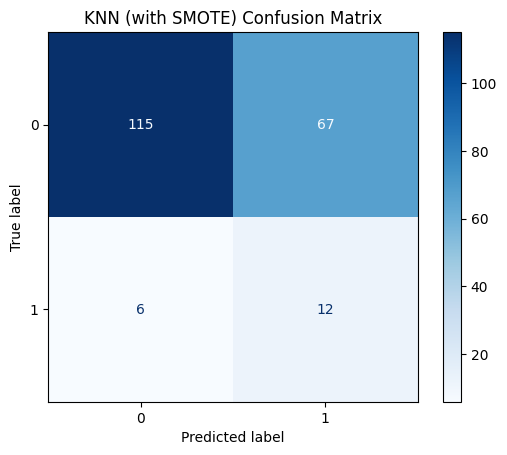

In [39]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Old Training Churn Ratio:\n", y_train.value_counts())
print("\nNew SMOTE Training Churn Ratio:\n", y_train_smote.value_counts())
print("-" * 50)

knn_smote = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = knn_smote.predict(X_test)

print("KNN with SMOTE Classification Report:\n")
print(classification_report(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Blues')
plt.title("KNN (with SMOTE) Confusion Matrix")
plt.show()

# 📊 Telecom Churn Prediction – Final Insights

---

## 🧠 1. Problem Objective

The goal of this project was to **predict customer churn** using machine learning and identify key drivers influencing churn behavior.

---

## 📊 2. Exploratory Data Analysis (EDA)

- Most numerical features showed **reasonable distributions**, while some (e.g., complaints, payment delay) were **right-skewed**
- Target variable (**Churn**) was **highly imbalanced**
- Behavioral features (complaints, support calls) showed strong variation

---

## 📉 3. Data Preprocessing

- Applied **log transformation (`log1p`)** on skewed features:
  - `Payment_Delay_Days`
  - `Complaints_Last_6M`
  - `Support_Calls`
- Applied **StandardScaler** to normalize numerical features
- Encoded categorical variables using **one-hot encoding (`drop_first=True`)**

---

## 🧪 4. Statistical Testing

### 🔹 T-Test (Continuous Features)
- Only **Tenure_Months** showed significant difference between churners and non-churners
- Other features were not statistically significant, indicating **non-linear relationships**

### 🔹 Chi-Square Test (Categorical Features)
- **Auto_Pay** showed significant relationship with churn
- **Internet_Speed_Mbps** and **Discount_Received_%** were not statistically significant

---

## 📏 5. Multicollinearity Check (VIF)

- All features had **VIF ≈ 1–2**, indicating:
  - No multicollinearity
  - Each feature contributes unique information
- Dataset is well-structured for regression modeling

---

## 🤖 6. Model Building

### 🔹 Logistic Regression (with class_weight='balanced')

#### Initial Model:
- High Recall (0.89) → captured most churners
- Low Precision (0.22) → many false positives

#### After Threshold Optimization:
- Precision improved to **0.47**
- Recall adjusted to **0.50**
- Accuracy improved to **91%**

👉 Achieved a **balanced and practical model**

---

### 🔹 KNN Model

#### Without SMOTE:
- High Accuracy (0.88)
- Very low Recall (0.28) → missed most churners

#### With SMOTE:
- Recall improved to **0.67**
- Precision dropped to **0.15**
- Accuracy dropped to **0.64**

👉 KNN is **highly sensitive to class imbalance and noise**

---

## 🏆 7. Model Comparison

| Model | Precision (Churn) | Recall (Churn) | Accuracy | Verdict |
|------|------------------|----------------|----------|--------|
| Logistic Regression | 0.47 | 0.50 | 0.91 | ✅ Best |
| KNN | 0.31 | 0.28 | 0.88 | ❌ Weak |
| KNN + SMOTE | 0.15 | 0.67 | 0.64 | ⚠️ Noisy |

👉 **Logistic Regression performed best overall**

---

## 📈 8. ROC Curve Insight

- ROC-AUC ≈ **0.88–0.90**
- Model shows strong ability to distinguish churn vs non-churn
- Threshold tuning significantly improved performance

---

## 🔍 9. Feature Importance (Logistic Regression)

### 🔥 Strong Positive Drivers of Churn:
- `Contract_Type_Monthly` → highest churn risk
- `Complaints_Last_6M` → dissatisfaction indicator
- `Payment_Delay_Days` → financial stress
- `Region_West` → regional influence

### 📉 Negative / Weak Drivers:
- `Usage_Hours`
- `Internet_Speed_Mbps`
- `Avg_Data_Usage_GB`

👉 Behavioral features are more important than usage metrics

---

## 💡 10. Key Business Insights

- Customers on **monthly contracts** are most likely to churn
- **Complaints and late payments** are strong early warning signals
- **Auto-pay users churn less**
- Discounts alone do not significantly reduce churn
- Regional differences suggest localized issues

---

## 🎯 11. Business Recommendations

1. Encourage customers to switch from **monthly → annual plans**
2. Improve **customer support and complaint resolution**
3. Monitor **payment delays as churn indicators**
4. Target **high-risk regions** with retention strategies
5. Use churn prediction model for **proactive retention campaigns**

---

## ⚖️ 12. Final Conclusion

- Statistical tests provided initial insights but were limited
- Machine learning models captured **complex and non-linear relationships**
- **Threshold tuning** played a critical role in balancing precision and recall
- Logistic Regression proved to be the **most stable and interpretable model**

---

## 🚀 13. Key Learning

> “Model performance is not just about accuracy — it’s about balancing business trade-offs between precision and recall.”

---

## Decision Tree

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       182
           1       0.22      0.22      0.22        18

    accuracy                           0.86       200
   macro avg       0.57      0.57      0.57       200
weighted avg       0.86      0.86      0.86       200

Decision Tree Confusion Matrix:

[[168  14]
 [ 14   4]]


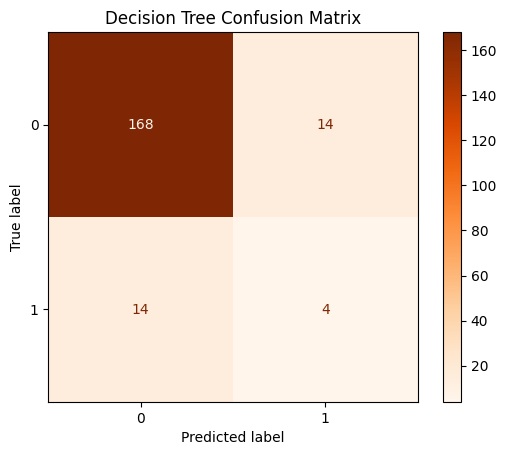

In [40]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap='Oranges')
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Random Forest

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.96       182
           1       1.00      0.06      0.11        18

    accuracy                           0.92       200
   macro avg       0.96      0.53      0.53       200
weighted avg       0.92      0.92      0.88       200

Random Forest Confusion Matrix:

[[182   0]
 [ 17   1]]


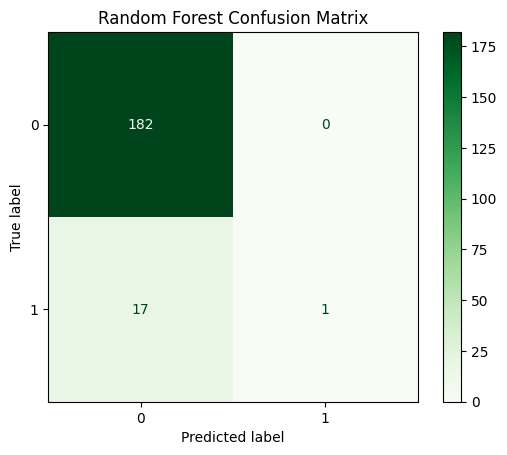

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    class_weight={0:1, 1:3},
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

## Cross Validation technique

In [42]:
from sklearn.model_selection import cross_val_score
models = {
    'Logistic Regression': lr,
    'KNN': knn_model,
    'KNN with SMOTE': knn_smote,
    'Decision Tree': dt,
    'Random Forest': rf
}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(f"{name} Cross-Validation F1 Scores: {scores}")
    print(f"{name} Average F1 Score: {scores.mean():.4f}\n")


Logistic Regression Cross-Validation F1 Scores: [0.27777778 0.21917808 0.23076923 0.34482759 0.36144578]
Logistic Regression Average F1 Score: 0.2868

KNN Cross-Validation F1 Scores: [0.22857143 0.125      0.25806452 0.20689655 0.30769231]
KNN Average F1 Score: 0.2252

KNN with SMOTE Cross-Validation F1 Scores: [0.28571429 0.         0.         0.2        0.27272727]
KNN with SMOTE Average F1 Score: 0.1517

Decision Tree Cross-Validation F1 Scores: [0.06896552 0.         0.06060606 0.12121212 0.10810811]
Decision Tree Average F1 Score: 0.0718

Random Forest Cross-Validation F1 Scores: [0.         0.         0.10526316 0.         0.        ]
Random Forest Average F1 Score: 0.0211



In [43]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [44]:
from imblearn.pipeline import Pipeline
pipeline_knn = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': lr,
    'KNN': knn_model,
    'KNN with SMOTE': pipeline_knn,
    'Decision Tree': dt,
    'Random Forest': rf
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    print(f"{name} CV F1 Scores: {scores}")
    print(f"{name} Avg F1: {scores.mean():.4f}\n")

Logistic Regression CV F1 Scores: [0.25       0.29268293 0.28571429 0.33333333 0.31111111]
Logistic Regression Avg F1: 0.2946

KNN CV F1 Scores: [0.12121212 0.24390244 0.08333333 0.28571429 0.22222222]
KNN Avg F1: 0.1913

KNN with SMOTE CV F1 Scores: [0.20224719 0.27659574 0.22535211 0.23809524 0.23913043]
KNN with SMOTE Avg F1: 0.2363

Decision Tree CV F1 Scores: [0.23076923 0.22857143 0.2        0.16216216 0.13636364]
Decision Tree Avg F1: 0.1916

Random Forest CV F1 Scores: [0.         0.         0.10526316 0.         0.1       ]
Random Forest Avg F1: 0.0411



## Logistic Regression Tunning

In [46]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_lr.fit(X_train, y_train)

print("Best Params:", grid_lr.best_params_)

Best Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


## Random Forest Tunning

In [47]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

print("Best Params:", random_search_rf.best_params_)

Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3}


## Re-evaluate tunned model

In [48]:
best_lr = grid_lr.best_estimator_
best_rf = random_search_rf.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

print("Tuned Logistic:\n", classification_report(y_test, y_pred_lr))
print("Tuned RF:\n", classification_report(y_test, y_pred_rf))

Tuned Logistic:
               precision    recall  f1-score   support

           0       0.98      0.69      0.81       182
           1       0.22      0.89      0.36        18

    accuracy                           0.71       200
   macro avg       0.60      0.79      0.58       200
weighted avg       0.92      0.71      0.77       200

Tuned RF:
               precision    recall  f1-score   support

           0       0.97      0.79      0.87       182
           1       0.25      0.72      0.38        18

    accuracy                           0.79       200
   macro avg       0.61      0.76      0.62       200
weighted avg       0.90      0.79      0.83       200

